# Estoque de Emprego × Estimativa por Saldo Acumulado
## Análise por Intensidade Tecnológica — 2022 em diante

Este notebook combina duas fontes de dados de emprego formal no Brasil:

- **Estoque de emprego (RAIS)**: dados anuais reais de trabalhadores formais por setor — anos disponíveis carregados dinamicamente (atualmente até 2024).
- **Saldo de emprego (CAGED)**: variação mensal de empregos formais (admissões − desligamentos) — disponível a partir de 2022.

### Objetivo

Para cada setor, plotar no mesmo gráfico:
1. Os **estoques reais** disponíveis a partir de 2022 (pontos negros em dezembro de cada ano).
2. As **trajetórias estimadas** de estoque para cada ano após o último estoque real — calculadas como  
   `estoque(ano-1) + saldo acumulado mês a mês do ano corrente`.  
   Esse é o método padrão de estimativa intraanual utilizado antes de a RAIS ser divulgada.

A comparação entre os pontos reais e o final de cada trajetória estimada mostra a qualidade da estimativa.

### Setores analisados

| Setor | Divisões CNAE |
|---|---|
| Total | Todos os setores |
| Indústria Geral | Extrativa (05–09) + Transformação (10–33) |
| Indústria de Transformação | 10–33 |
| Alta Intensidade Tecnológica | 21, 26, 30 |
| Média Alta Intensidade Tecnológica | 20, 27, 28, 29 |
| Média Intensidade Tecnológica | 19, 22, 23, 24, 25, 33 |

> **Classificação OCDE** de intensidade tecnológica aplicada ao nível de divisão da CNAE 2.0.

---
## 1. Configuração e Importações

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Ajuste de path para execução local (desenvolvimento)
notebook_dir = os.path.abspath('')
parent_dir = os.path.dirname(notebook_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sdic_libraries.data_access.emprego import (
    get_estoque_emprego_nacional,
    get_saldo_emprego_nacional_mensal_agrupado,
)

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


---
## 2. Definição dos Grupos CNAE

In [2]:
# Indústria de Transformação: divisões 10 a 33
ind_transf = [str(i) for i in range(10, 34)]

# Indústria Geral: Extrativa (05–09) + Transformação (10–33)
ind_geral = ['05', '06', '07', '08', '09'] + ind_transf

# Alta Intensidade Tecnológica (OCDE)
# 21 = Farmacêutica | 26 = Eletrônica/Óptica | 30 = Outros Transportes (inclui aeronaves)
alta_it = ['21', '26', '30']

# Média Alta Intensidade Tecnológica (OCDE)
# 20 = Química | 27 = Elétrica | 28 = Máquinas e Equipamentos | 29 = Veículos Automotores
media_alta_it = ['20', '27', '28', '29']

# Média Intensidade Tecnológica (OCDE)
# 19 = Petróleo/Coque | 22 = Borracha e Plástico | 23 = Minerais Não Metálicos
# 24 = Metalurgia | 25 = Produtos de Metal | 33 = Manutenção de Máquinas
media_it = ['19', '22', '23', '24', '25', '33']

# Dicionário de grupos (Total será adicionado após coleta do estoque)
grupos_cnae = {
    'Indústria Geral': ind_geral,
    'Indústria de Transformação': ind_transf,
    'Alta Intensidade Tecnológica': alta_it,
    'Média Alta Intensidade Tecnológica': media_alta_it,
    'Média Intensidade Tecnológica': media_it,
}

print('Grupos CNAE definidos:')
for nome, codigos in grupos_cnae.items():
    preview = codigos[:5]
    sufixo = '...' if len(codigos) > 5 else ''
    print(f'  {nome}: {len(codigos)} divisões → {preview}{sufixo}')

Grupos CNAE definidos:
  Indústria Geral: 29 divisões → ['05', '06', '07', '08', '09']...
  Indústria de Transformação: 24 divisões → ['10', '11', '12', '13', '14']...
  Alta Intensidade Tecnológica: 3 divisões → ['21', '26', '30']
  Média Alta Intensidade Tecnológica: 4 divisões → ['20', '27', '28', '29']
  Média Intensidade Tecnológica: 6 divisões → ['19', '22', '23', '24', '25']...


---
## 3. Coleta de Dados de Estoque (RAIS)

Uma única chamada retorna o estoque agregado por divisão CNAE e ano para todo o Brasil. Em seguida, filtramos por grupo e somamos.

In [3]:
print('Coletando estoque de emprego nacional (RAIS)...')
df_estoque_raw = get_estoque_emprego_nacional(nivel_cnae=2, agregado=True)
df_estoque_raw['ano'] = df_estoque_raw['ano'].astype(int)
df_estoque_raw['divisao_cnae_cod'] = df_estoque_raw['divisao_cnae_cod'].astype(str)

print(f'  Registros brutos: {len(df_estoque_raw)}')
print(f'  Anos disponíveis na API: {sorted(df_estoque_raw["ano"].unique())}')

# Lista de todos os CNAEs presentes — usada para o grupo "Total"
todos_cnaes = sorted(df_estoque_raw['divisao_cnae_cod'].unique().tolist())
print(f'  CNAEs disponíveis: {len(todos_cnaes)} divisões')

# Filtro temporal: todos os anos disponíveis a partir de 2002
ANO_INICIO = 2002
df_estoque = df_estoque_raw[df_estoque_raw['ano'] >= ANO_INICIO].copy()
anos_disponiveis = sorted(df_estoque['ano'].unique().tolist())
print(f'  Anos incluídos (>= {ANO_INICIO}): {anos_disponiveis}')

# Calcular estoque anual por setor
estoque_por_setor = {}

# Total
estoque_por_setor['Total'] = (
    df_estoque.groupby('ano')['estoque_trabalhadores'].sum().reset_index()
)

# Demais grupos
for nome, codigos in grupos_cnae.items():
    mask = df_estoque['divisao_cnae_cod'].isin(codigos)
    estoque_por_setor[nome] = (
        df_estoque[mask].groupby('ano')['estoque_trabalhadores'].sum().reset_index()
    )

# Tabela de resumo com anos dinâmicos
print('\nEstoque anual por setor (trabalhadores):')
cabecalho = f'{"Setor":<40}' + ''.join(f'{a:>15}' for a in anos_disponiveis)
print(cabecalho)
print('-' * (40 + 15 * len(anos_disponiveis)))
for nome, df in estoque_por_setor.items():
    d = df.set_index('ano')['estoque_trabalhadores']
    linha = f'{nome:<40}' + ''.join(
        f'{d[a]:>15,.0f}' if a in d.index else f'{"N/D":>15}' for a in anos_disponiveis
    )
    print(linha)

Coletando estoque de emprego nacional (RAIS)...
  Registros brutos: 1000
  Anos disponíveis na API: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
  CNAEs disponíveis: 87 divisões
  Anos incluídos (>= 2002): [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Estoque anual por setor (trabalhadores):
Setor                                              2014           2015           2016           2017           2018           2019           2020           2021           2022           2023           2024           2025
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Total                                        45,339,976     96,121,614     92,120,396    

---
## 4. Coleta de Saldo Mensal (CAGED)

Para cada grupo, coletamos o saldo mensal agregado de 2022 a 2025. São 6 chamadas no total.

In [4]:
grupos_para_saldo = {'Total': todos_cnaes, **grupos_cnae}

print(f'Coletando saldo mensal de emprego (CAGED, {ANO_INICIO} em diante)...')
print(f'  {len(grupos_para_saldo)} grupos a processar\n')

saldo_por_setor = {}

for nome, codigos in grupos_para_saldo.items():
    print(f'  [{list(grupos_para_saldo).index(nome)+1}/{len(grupos_para_saldo)}] {nome} ({len(codigos)} CNAEs)...', end=' ', flush=True)
    df_s = get_saldo_emprego_nacional_mensal_agrupado(
        nome_grupo=nome,
        lista_cnae=codigos,
        data_minima=f'{ANO_INICIO}-01-01',
    )
    df_s['mes_referencia'] = pd.to_datetime(df_s['mes_referencia'])
    df_s = df_s.sort_values('mes_referencia').reset_index(drop=True)
    saldo_por_setor[nome] = df_s
    dmin = df_s['mes_referencia'].min().strftime('%m/%Y')
    dmax = df_s['mes_referencia'].max().strftime('%m/%Y')
    print(f'{len(df_s)} registros ({dmin} – {dmax})')

print('\nColeta concluída.')

Coletando saldo mensal de emprego (CAGED, 2002 em diante)...
  6 grupos a processar

  [1/6] Total (87 CNAEs)... 39 registros (01/2023 – 03/2026)
  [2/6] Indústria Geral (29 CNAEs)... 39 registros (01/2023 – 03/2026)
  [3/6] Indústria de Transformação (24 CNAEs)... 39 registros (01/2023 – 03/2026)
  [4/6] Alta Intensidade Tecnológica (3 CNAEs)... 39 registros (01/2023 – 03/2026)
  [5/6] Média Alta Intensidade Tecnológica (4 CNAEs)... 39 registros (01/2023 – 03/2026)
  [6/6] Média Intensidade Tecnológica (6 CNAEs)... 39 registros (01/2023 – 03/2026)

Coleta concluída.


---
## 5. Função de Visualização

Para cada setor, o gráfico sobrepõe:
- **Pontos negros**: estoque real anual (RAIS) em dezembro de cada ano disponível.
- **Linhas tracejadas**: trajetórias estimadas — `estoque(Y-1) + saldo acumulado mês a mês do ano Y` — para cada ano com saldo CAGED disponível.
- **Diamantes coloridos**: ponto final de cada trajetória estimada (estimativa de dezembro do ano Y).

Os anos e cores são derivados dinamicamente dos dados disponíveis.

In [5]:
def plot_estoque_vs_estimado(nome, df_stock, df_saldo, ax=None):
    """Compara estoque real anual com trajetória estimada via saldo acumulado.

    Anos e cores são derivados dinamicamente: as trajetórias cobrem do
    (menor_ano_real + 1) até (maior_ano_real + 1), ou seja, o último ano
    estimado é sempre o ano seguinte ao último estoque real disponível.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(13, 6))

    stock_dict = df_stock.set_index('ano')['estoque_trabalhadores'].to_dict()

    # Anos estimados: do segundo ano real até um ano além do último real
    anos_reais = sorted(stock_dict.keys())
    anos_estimados = list(range(min(anos_reais) + 1, max(anos_reais) + 2))

    # Paleta de cores para as trajetórias estimadas
    _palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    cores_ano = {a: _palette[i % len(_palette)] for i, a in enumerate(anos_estimados)}

    df_s = df_saldo.copy()
    df_s['_mes'] = pd.to_datetime(df_s['mes_referencia'])

    def fmt_val(v):
        if abs(v) >= 1e6:
            return f'{v/1e6:.2f}M'
        return f'{v/1e3:.0f}k'

    # Estoque real (pontos negros) — todos os anos disponíveis
    for i, ano in enumerate(anos_reais):
        val = stock_dict[ano]
        ax.scatter(
            pd.Timestamp(f'{ano}-12-31'), val,
            color='black', zorder=6, s=90, marker='o',
            label='Estoque Real (RAIS)' if i == 0 else '_nolegend_'
        )
        ax.annotate(
            fmt_val(val),
            xy=(pd.Timestamp(f'{ano}-12-31'), val),
            xytext=(6, 6), textcoords='offset points',
            fontsize=8, color='black', fontweight='bold'
        )

    # Trajetórias estimadas: base(ano-1) + saldo acumulado
    for year in anos_estimados:
        base = stock_dict.get(year - 1)
        if base is None:
            continue
        s = df_s[df_s['_mes'].dt.year == year].sort_values('_mes').copy()
        if s.empty:
            continue
        s['est'] = base + s['saldo_reajustado'].cumsum()
        cor = cores_ano[year]
        ax.plot(
            s['_mes'], s['est'],
            color=cor, linestyle='--', linewidth=1.8,
            label=f'Estoque {year-1} + saldo acum. {year}'
        )
        # Diamante no ponto final (estimativa de dezembro)
        ax.scatter(
            s['_mes'].iloc[-1], s['est'].iloc[-1],
            color=cor, marker='D', s=70, zorder=5
        )
        ax.annotate(
            fmt_val(s['est'].iloc[-1]),
            xy=(s['_mes'].iloc[-1], s['est'].iloc[-1]),
            xytext=(6, -14), textcoords='offset points',
            fontsize=7.5, color=cor
        )

    # Formatação
    ax.set_title(nome, fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('Trabalhadores formais', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)

    def fmt_y(x, _):
        if abs(x) >= 1e6:
            return f'{x/1e6:.1f}M'
        elif abs(x) >= 1e3:
            return f'{x/1e3:.0f}k'
        return str(int(x))

    ax.yaxis.set_major_formatter(plt.FuncFormatter(fmt_y))
    ax.legend(fontsize=9, loc='upper left', framealpha=0.85)
    ax.grid(True, alpha=0.3, linestyle=':')
    return ax

print('Função de visualização definida.')

Função de visualização definida.


In [ ]:
def build_serie_continua(df_stock, df_saldo):
    """Série mensal contínua ancorada nos pontos RAIS.

    Para cada par de anos RAIS consecutivos:
    - Se há dados CAGED: usa a trajetória de saldo acumulado com correção linear
      distribuída para que o último mês coincida exatamente com o RAIS seguinte.
    - Sem CAGED: interpolação linear simples entre os dois pontos RAIS.
    Após o último RAIS: extensão direta via saldo CAGED acumulado.
    """
    stock_dict = df_stock.set_index('ano')['estoque_trabalhadores'].to_dict()
    anos_reais = sorted(stock_dict.keys())

    df_s = df_saldo.copy()
    df_s['_mes'] = pd.to_datetime(df_s['mes_referencia'])

    registros = [{'data': pd.Timestamp(f'{anos_reais[0]}-12-31'),
                  'estoque': stock_dict[anos_reais[0]], 'tipo': 'rais'}]

    for i in range(len(anos_reais) - 1):
        ano_ini, ano_fim = anos_reais[i], anos_reais[i + 1]
        base, target = stock_dict[ano_ini], stock_dict[ano_fim]

        s_ano = df_s[df_s['_mes'].dt.year == ano_fim].sort_values('_mes').reset_index(drop=True).copy()
        if not s_ano.empty:
            s_ano['est_raw'] = base + s_ano['saldo_reajustado'].cumsum()
            residuo = target - s_ano['est_raw'].iloc[-1]
            n = len(s_ano)
            # Correção linear distribuída: último mês ajustado = target
            s_ano['est_adj'] = s_ano['est_raw'] + residuo * (s_ano.index + 1) / n
            for _, row in s_ano.iterrows():
                registros.append({'data': row['_mes'], 'estoque': row['est_adj'], 'tipo': 'ajustado'})
        else:
            for m in range(1, 13):
                dt = pd.Timestamp(year=ano_fim, month=m, day=1) + pd.offsets.MonthEnd(0)
                registros.append({'data': dt, 'estoque': base + (target - base) * m / 12, 'tipo': 'linear'})

    # Extensão após o último RAIS com saldo CAGED bruto
    ultimo_ano = anos_reais[-1]
    s_ext = df_s[df_s['_mes'].dt.year > ultimo_ano].sort_values('_mes').copy()
    if not s_ext.empty:
        s_ext['est'] = stock_dict[ultimo_ano] + s_ext['saldo_reajustado'].cumsum()
        for _, row in s_ext.iterrows():
            registros.append({'data': row['_mes'], 'estoque': row['est'], 'tipo': 'estimado'})

    return pd.DataFrame(registros).sort_values('data').reset_index(drop=True)


def plot_serie_continua(nome, df_stock, df_saldo, ax=None):
    """Plota série contínua mensal com pontos RAIS como âncoras e extensão CAGED."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 6))

    serie = build_serie_continua(df_stock, df_saldo)
    stock_dict = df_stock.set_index('ano')['estoque_trabalhadores'].to_dict()
    anos_reais = sorted(stock_dict.keys())
    ultimo_rais = anos_reais[-1]

    hist = serie[serie['tipo'].isin(['rais', 'linear', 'ajustado'])]
    est = serie[serie['tipo'] == 'estimado']

    ax.plot(hist['data'], hist['estoque'], color='steelblue', linewidth=1.8,
            label='Série histórica (RAIS + interpolação ajustada pelo CAGED)')

    if not est.empty:
        conn = pd.concat([hist.tail(1), est])
        ax.plot(conn['data'], conn['estoque'], color='darkorange', linewidth=1.8,
                linestyle='--', label=f'Estimativa CAGED (após RAIS {ultimo_rais})')

    for i, ano in enumerate(anos_reais):
        ax.scatter(pd.Timestamp(f'{ano}-12-31'), stock_dict[ano],
                   color='black', s=70, zorder=6,
                   label='Estoque Real (RAIS)' if i == 0 else '_nolegend_')

    def fmt_y(x, _):
        if abs(x) >= 1e6:
            return f'{x/1e6:.1f}M'
        elif abs(x) >= 1e3:
            return f'{x/1e3:.0f}k'
        return str(int(x))

    ax.set_title(nome, fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('Trabalhadores formais', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(fmt_y))
    ax.legend(fontsize=9, loc='upper left', framealpha=0.85)
    ax.grid(True, alpha=0.3, linestyle=':')
    return ax

print('Funções de série contínua definidas.')

---
## 6. Gráficos por Setor

### 6.1 Total — Todos os Setores

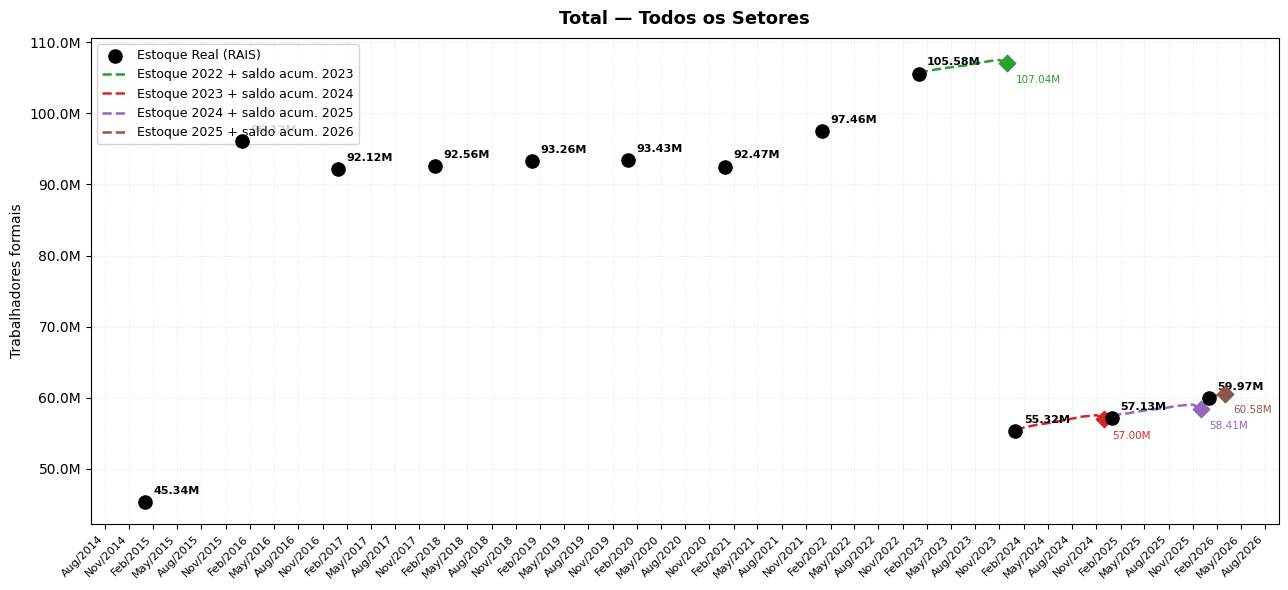

In [6]:
fig, ax = plt.subplots(figsize=(13, 6))
plot_estoque_vs_estimado(
    'Total — Todos os Setores',
    estoque_por_setor['Total'],
    saldo_por_setor['Total'],
    ax=ax
)
plt.tight_layout()
plt.show()

#### Total — Todos os Setores (a partir de 2023)

In [ ]:
df_total_2022plus = estoque_por_setor['Total'][estoque_por_setor['Total']['ano'] >= 2022]

fig, ax = plt.subplots(figsize=(13, 6))
plot_estoque_vs_estimado(
    'Total — Todos os Setores (a partir de 2023)',
    df_total_2022plus,
    saldo_por_setor['Total'],
    ax=ax
)
ax.set_xlim(pd.Timestamp('2023-01-01'), None)
plt.tight_layout()
plt.show()

#### Total — Série Contínua Mensal (Interpolação Ajustada + Estimativa CAGED)

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
plot_serie_continua(
    'Total — Série Contínua Mensal',
    estoque_por_setor['Total'],
    saldo_por_setor['Total'],
    ax=ax
)
ax.set_xlim(pd.Timestamp('2022-01-01'), None)
plt.tight_layout()
plt.show()

### 6.2 Indústria Geral (Extrativa + Transformação)

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
plot_estoque_vs_estimado(
    'Indústria Geral (Extrativa + Transformação)',
    estoque_por_setor['Indústria Geral'],
    saldo_por_setor['Indústria Geral'],
    ax=ax
)
plt.tight_layout()
plt.show()

### 6.3 Indústria de Transformação (CNAE 10–33)

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
plot_estoque_vs_estimado(
    'Indústria de Transformação (CNAE 10–33)',
    estoque_por_setor['Indústria de Transformação'],
    saldo_por_setor['Indústria de Transformação'],
    ax=ax
)
plt.tight_layout()
plt.show()

### 6.4 Alta Intensidade Tecnológica (CNAE 21, 26, 30)

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
plot_estoque_vs_estimado(
    'Alta Intensidade Tecnológica (CNAE 21, 26, 30)',
    estoque_por_setor['Alta Intensidade Tecnológica'],
    saldo_por_setor['Alta Intensidade Tecnológica'],
    ax=ax
)
plt.tight_layout()
plt.show()

### 6.5 Média Alta Intensidade Tecnológica (CNAE 20, 27, 28, 29)

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
plot_estoque_vs_estimado(
    'Média Alta Intensidade Tecnológica (CNAE 20, 27, 28, 29)',
    estoque_por_setor['Média Alta Intensidade Tecnológica'],
    saldo_por_setor['Média Alta Intensidade Tecnológica'],
    ax=ax
)
plt.tight_layout()
plt.show()

### 6.6 Média Intensidade Tecnológica (CNAE 19, 22, 23, 24, 25, 33)

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
plot_estoque_vs_estimado(
    'Média Intensidade Tecnológica (CNAE 19, 22, 23, 24, 25, 33)',
    estoque_por_setor['Média Intensidade Tecnológica'],
    saldo_por_setor['Média Intensidade Tecnológica'],
    ax=ax
)
plt.tight_layout()
plt.show()

---
## 7. Nota Metodológica

### Fontes de dados

| Fonte | Periodicidade | Defasagem | Uso neste notebook |
|---|---|---|---|
| **RAIS** (Relação Anual de Informações Sociais) | Anual | ~12 meses | Estoque real (pontos negros) |
| **CAGED** (Cadastro Geral de Empregados e Desempregados) | Mensal | ~30 dias | Saldo mensal → trajetória estimada |

### Interpretação dos gráficos

- **Ponto negro próximo ao diamante** → boa qualidade da estimativa CAGED para o setor.
- **Divergência crescente ao longo do ano** → possível viés no saldo CAGED (cobertura incompleta, reajuste estatístico, etc.).
- **Trajetória de 2025** (verde): não possui ponto de validação real, pois a RAIS 2025 ainda não foi publicada.

### Classificação OCDE de intensidade tecnológica (nível divisão CNAE 2.0)

| Intensidade | Divisões | Descrição resumida |
|---|---|---|
| Alta | 21, 26, 30 | Farmacêutica, Eletrônica/Óptica, Outros Transportes (incl. aeronaves) |
| Média Alta | 20, 27, 28, 29 | Química, Equipamentos Elétricos, Máquinas, Veículos Automotores |
| Média | 19, 22, 23, 24, 25, 33 | Petróleo, Borracha/Plástico, Minerais, Metalurgia, Metal, Manutenção |
| Baixa | demais 10–18, 31, 32 | Alimentos, Têxtil, Vestuário, Papel, Móveis, Produtos Diversos |

> Referência: OCDE (2011), *ISIC Rev. 3 Technology Intensity Definition*, adaptado ao CNAE 2.0.